# **Analysis of The Famous Titanic Dataset of Kaggle**

In [1]:
from PIL import Image as i

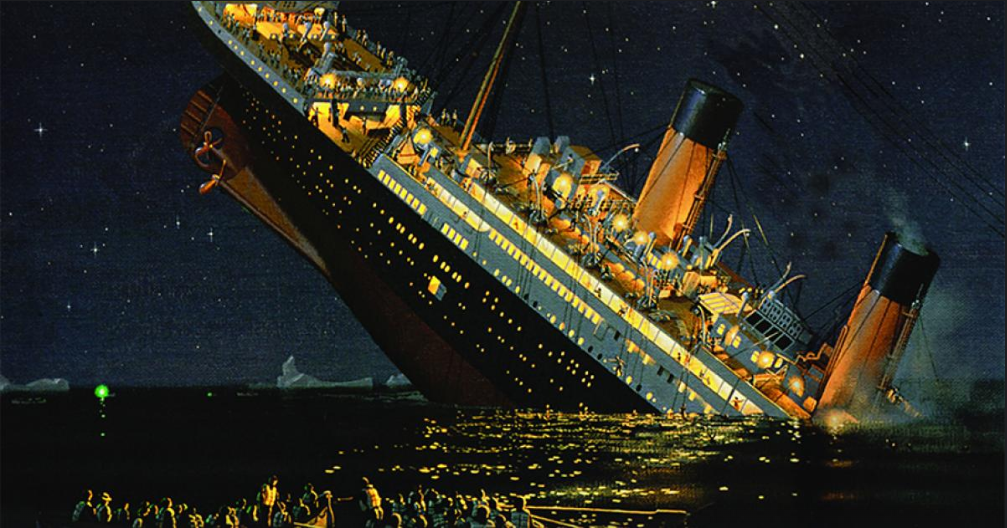

In [2]:
i.open('titanic.png')

# *1. Load all the libraries*

In [3]:
%store -r my_library

In [4]:
my_library

All the libraries are loaded successfully! ✅


In [5]:
print(my_library)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import numpy as np
import sklearn       
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy import stats                    # statistical tests
import statsmodels.api as sm              # regression, statistical models
import pyarrow.parquet as pq              # direct parquet schema inspection
import glob                               # find multiple files (*.parquet, *.csv)
import json                               # read/write JSON files
from pathlib import Path                  # better than os for file paths
import warnings
warnings.filterwarnings('ignore')          # suppress unnecessary warnings

pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.max_rows', 100)      # show more rows
pd.set_option('display.float_format', '{:.2f

# *2. Load the Dataset to work with*

In [6]:
df = pd.read_csv('titanic_data.csv')
print(f"Shape of dataset \nRows : {df.shape[0] }\ncolumns : {df.shape[1]}")
df.head(10)

Shape of dataset 
Rows : 891
columns : 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.46,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.00,0,0,17463,51.86,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.07,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.00,0,2,347742,11.13,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.00,1,0,237736,30.07,NaN,C


## 3. Description and detailed overview of the dataset

In [7]:
df.size

10692

## 4. Coulmn Description with non-null counts

#### **4.1 Column Description**
| **Column** | **Description** |
|--------|-------------|
|**Passenger ID:** |A unique Identification number assigend for each passenger|
|**Survived**|0 : Did not Survived,1 : Survived |
|**Pclass(Passenger Class)**|Ticket Classes, 1: Upper Class,2: Middle Class,3: Lower Class|
|**Name**|Name of each passenger|
|**Sex**|Gender of each passenger|
|**Age**|Age of each passenger in Years|
|**SibSp**|Number of Siblings/Spouses Aboard|
|**Parch**|Number of parents/Children Aboard|
|**Ticket**|Ticket Number of each passenger|
|**Fare**|Passenger Fare|
|**Cabin**|Cabin number of each passenger|
|**Embarked**|Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton|

#### **4.2 NON-NULL COUNTS**

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# *5. Statistical Description of the dataset having numerical column data*

In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


# *6. Statistical Description of the Dataset having Categorical Column*

In [10]:
df.describe(include = 'object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


# *7. Finding the amount of missing data*

In [11]:
missing_data = df.isna().sum().reset_index()
missing_data.rename(columns = {'index' : 'Attributes',0:'Sum_of_missing_data'},inplace = True)
missing_data

,Attributes,Sum_of_missing_data
0,PassengerId,0
1,Survived,0
2,Pclass,0
3,Name,0
4,Sex,0
5,Age,177
6,SibSp,0
7,Parch,0
8,Ticket,0
9,Fare,0


In [12]:
missing_data = missing_data.drop(missing_data[missing_data['Sum_of_missing_data']==0].index)
missing_data

,Attributes,Sum_of_missing_data
5,Age,177
10,Cabin,687
11,Embarked,2


In [13]:
missing_data = missing_data.set_index(missing_data['Attributes'])
missing_data

,Attributes,Sum_of_missing_data
Attributes,,
Age,Age,177
Cabin,Cabin,687
Embarked,Embarked,2


In [14]:
missing_data['Missing_percentage'] = (df.isna().sum()/len(df)).round(2)
missing_data

,Attributes,Sum_of_missing_data,Missing_percentage
Attributes,,,
Age,Age,177,0.20
Cabin,Cabin,687,0.77
Embarked,Embarked,2,0.00


# *8. Visualizing the missing data*

In [15]:
sns.set_style('darkgrid')

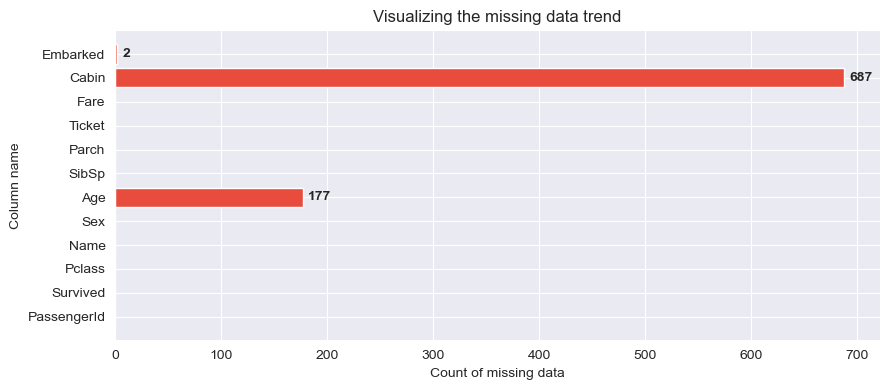

In [16]:
fig , ax = plt.subplots(figsize = (9,4));
colors = ['#e74c3c' if df[col].isna().any() else '#2ecc71' for col in df.columns];
ax.barh(df.columns,df.isna().sum(),color = colors);
for i,v in enumerate(df.isna().sum()):
    if v > 0:
        ax.text(v+5,i,str(v),va = 'center',fontweight = 'bold')
ax.set_xlabel('Count of missing data')
ax.set_ylabel('Column name')
ax.set_title('Visualizing the missing data trend')
plt.tight_layout()

# **KEY OBSERVATIONS :**

 * 77% of the **Cabin data** is missing.So we can drop it.
 * **Only** 2% data missing in **Embarked Data**.
 * 20% of the **Age Data** is missing.

In [17]:
df.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [18]:
survive_count = df['Survived'].value_counts().reset_index()
survive_count

,Survived,count
0,0,549
1,1,342


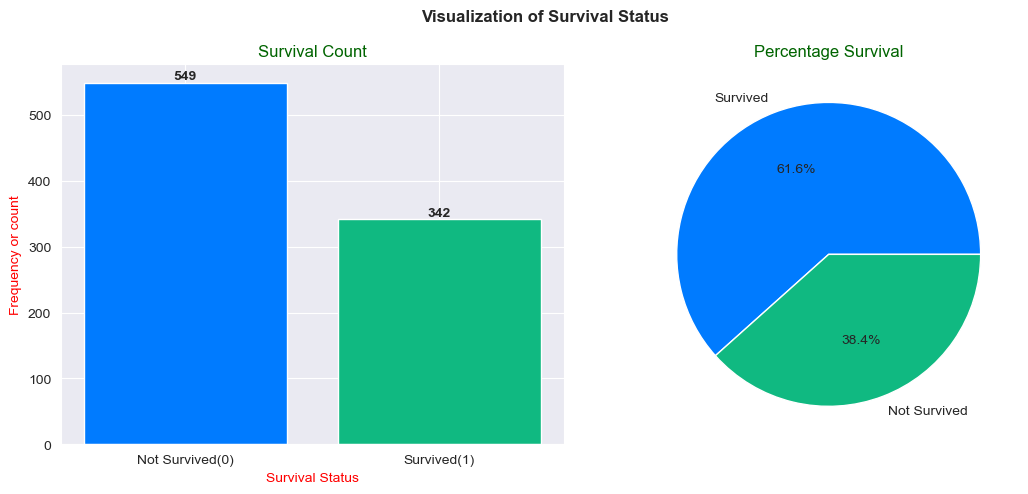

**Survival Rate**: 38.38%
Death Rate : 61.62%


In [19]:
fig,ax = plt.subplots(1,2,figsize = (11,5));
#bar plot
ax[0].bar(['Not Survived(0)','Survived(1)'],survive_count['count'],color  = ['#007BFF','#10B981']);
ax[0].set_xlabel('Survival Status',c = 'red');
ax[0].set_ylabel('Frequency or count',c = 'red');
ax[0].set_title('Survival Count',c = 'darkgreen')
for i,v in enumerate(survive_count['count']):
    ax[0].text(i,v+5,str(v),fontweight = 'bold',ha = 'center')
# pie chart
ax[1].pie(survive_count['count'],labels = ['Survived','Not Survived'],autopct = '%1.1f%%',colors = ['#007BFF','#10B981']);   
ax[1].set_title('Percentage Survival',c = 'darkgreen')
plt.suptitle("Visualization of Survival Status",fontweight = 'bold')
plt.tight_layout()
plt.show()
print('**Survival Rate**: 'f"{df['Survived'].mean():.2%}")
print('Death Rate : 'f"{1-df['Survived'].mean():.2%}")

From this we can conclude that the survival rate was too low and death

In [20]:
passenger_count_per_class = df.groupby(['Pclass'])['Name'].count().reset_index()
passenger_count_per_class = passenger_count_per_class.rename(columns  = {'Name': 'Count of Passengers'})
passenger_count_per_class = passenger_count_per_class.sort_values(by = 'Count of Passengers',ascending = False)
passenger_count_per_class

,Pclass,Count of Passengers
2,3,491
0,1,216
1,2,184


In [21]:
age_counts = df['Age'].value_counts().reset_index()
age_counts

,Age,count
0,24.00,30
1,22.00,27
2,18.00,26
3,19.00,25
4,28.00,25
5,30.00,25
6,21.00,24
7,25.00,23
8,36.00,22
9,29.00,20


### **MOST(30) of the passengers were of age 24**

In [22]:
age_counts['count'].max()

30

In [23]:
age_counts['count'].min()

1

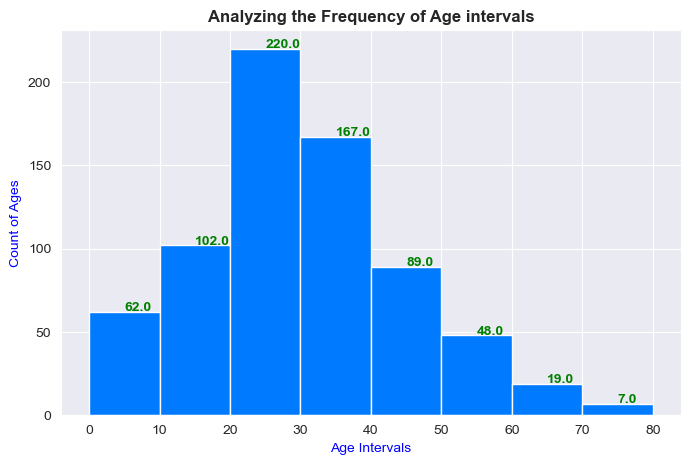

In [24]:
age = np.arange(0,81,10);
fig,ax = plt.subplots(figsize = (8,5));
counts,edges,bars = ax.hist(df['Age'],bins = age,color = '#007BFF',alpha = 1);
ax.set_xlabel('Age Intervals',c = 'blue')
ax.set_ylabel('Count of Ages',c = 'blue')
ax.set_title('Analyzing the Frequency of Age intervals',fontweight = 'bold')
for bar in bars:
    height = bar.get_height()
    ax.text(
            bar.get_x()+bar.get_width()/2 # x axis position
            ,height+0.5 # y axis position
            ,str(height) # The main text
            ,fontweight = 'bold'
            ,color = 'green'
           )

### **From the above histogram we can observe that majority of the population was of the age group of 20 to 30 yrs**

In [25]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

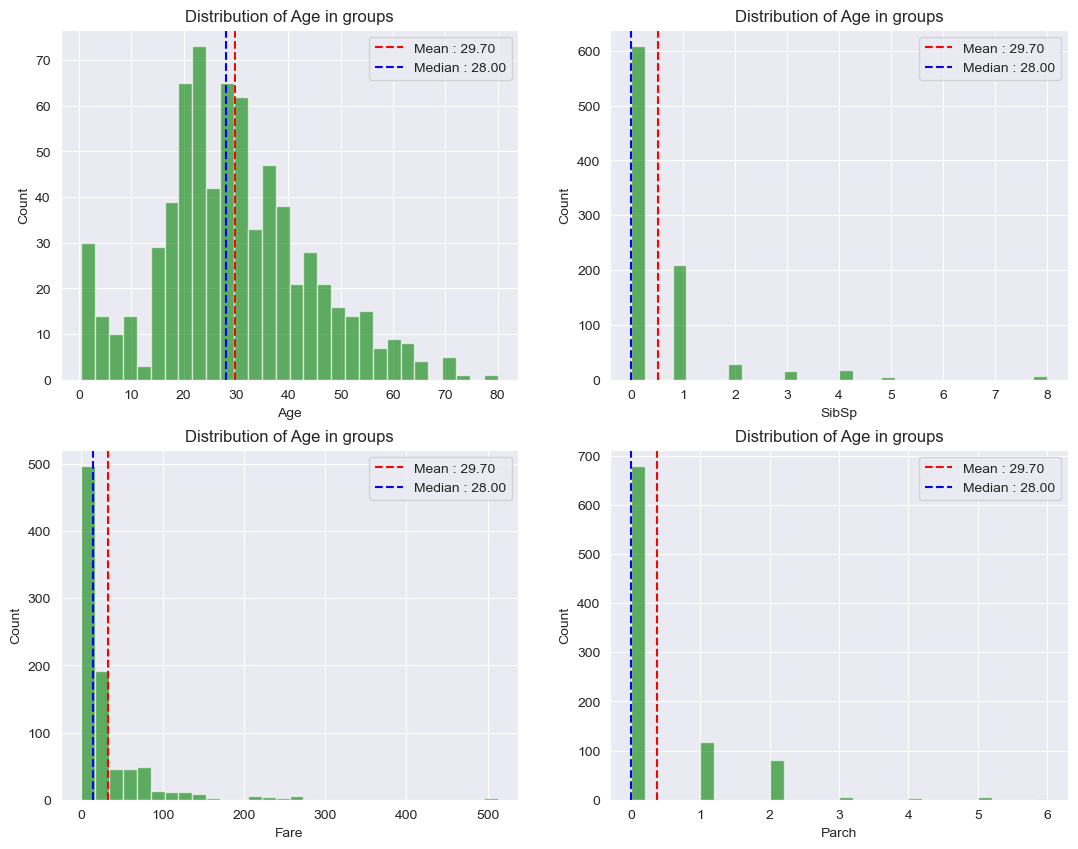

In [26]:
numerical_columns = ['Age','SibSp','Fare','Parch']
fig,axes = plt.subplots(2,2,figsize = (13,10));
axes = axes.flatten();
for i,v in enumerate(numerical_columns):
    axes[i].hist(df[v],bins = 30,color = 'green',alpha = 0.6);
    axes[i].set_xlabel(v);
    axes[i].set_ylabel('Count');
    axes[i].set_title('Distribution of Age in groups');
# drawing vertical lines for mean and median
    axes[i].axvline(df[v].mean(),color = 'red',linestyle = '--',label = f'Mean : {df['Age'].mean():.2f}')
    axes[i].axvline(df[v].median(),color = 'blue',linestyle = '--',label = f'Median : {df['Age'].median():.2f}')
    axes[i].legend();

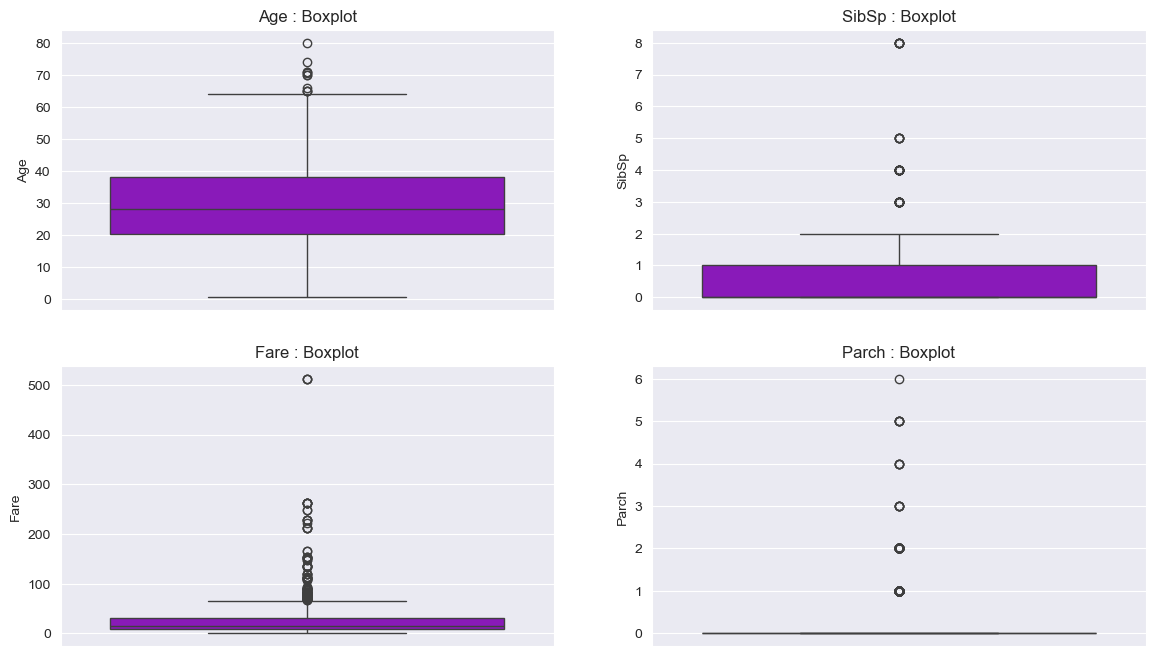

In [27]:
fig,ax = plt.subplots(2,2,figsize = (14,8))
ax = ax.flatten()
for i,v in enumerate(numerical_columns):
    sns.boxplot(y = df[v],ax = ax[i],color = 'darkviolet')
    ax[i].set_title(f'{v} : Boxplot')

# *9. Univariate Analysis Categorial Data*

In [28]:
s = df['Sex'].value_counts().reset_index()
s

,Sex,count
0,male,577
1,female,314


In [29]:
d = df['Embarked'].value_counts().reset_index()
d
#C = Cherbourg, Q = Queenstown, S = Southampton

,Embarked,count
0,S,644
1,C,168
2,Q,77


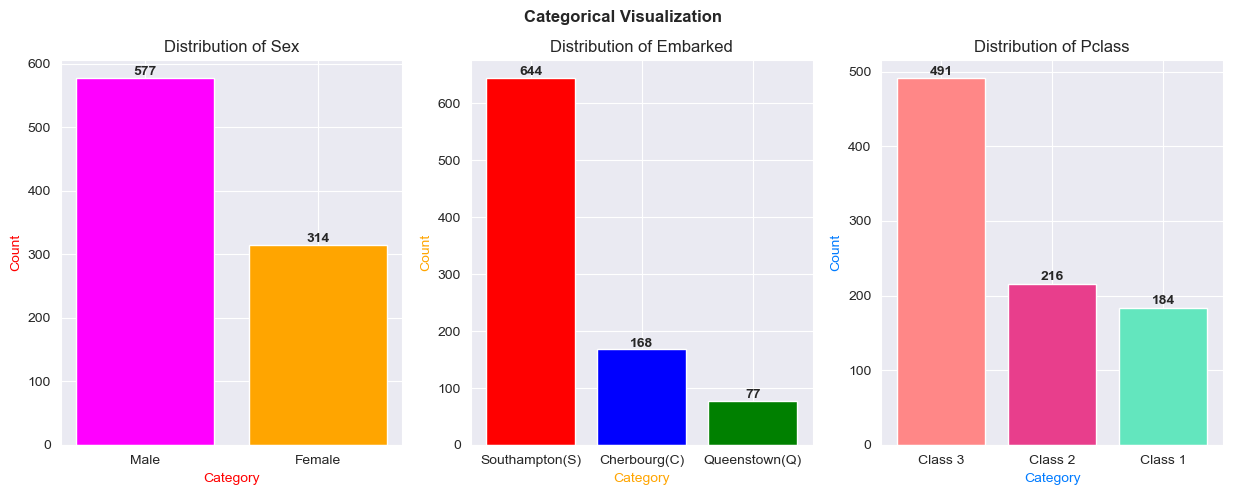

In [30]:
fig,ax = plt.subplots(1,3,figsize = (15,5));
#plot for sex column
ax[0].bar(['Male','Female'],s['count'],color = ['magenta','orange']);
for i,v in enumerate(s['count']):
    ax[0].text(i,v+5,str(v),fontweight = 'bold',ha = 'center');
ax[0].set_xlabel('Category',c = 'red');
ax[0].set_ylabel('Count',c = 'red');
ax[0].set_title('Distribution of Sex');

# plot for embarked column
ax[1].bar(['Southampton(S)','Cherbourg(C)','Queenstown(Q)'],d['count'],color = ['red','blue','green'])
for j,u in enumerate(d['count']):
    ax[1].text(j,u+5,str(u),fontweight = 'bold',ha = 'center')
ax[1].set_xlabel('Category',c = 'orange')
ax[1].set_ylabel('Count',c = 'orange')
ax[1].set_title('Distribution of Embarked')
plt.suptitle('Categorical Visualization',fontweight = 'bold')

# plot for Passenger class column
ax[2].bar(['Class 3','Class 2','Class 1'],passenger_count_per_class['Count of Passengers'],color = ['#FF8787','#E83E8C','#63E6BE'])
ax[2].set_xlabel('Category',c = '#007BFF')
ax[2].set_ylabel('Count',c = '#007BFF')
ax[2].set_title('Distribution of Pclass')
for i,v in enumerate(passenger_count_per_class['Count of Passengers']):
    plt.text(i,v+5,str(v),fontweight = 'bold',ha = 'center')

## **observations from the above plot**  : 
 * #### **There were more male passengers as compared to female passengers in the ship** 
 * #### **Most of the people boarded the ship at Southampton(s)**
 * #### **The majority of the passengers were in 3rd Class**

# *10. Bivariate Analysis of Survival Rate*

In [31]:
f = df.groupby('Sex')['Survived'].mean().reset_index()
f

,Sex,Survived
0,female,0.74
1,male,0.19


In [32]:
c = df.groupby('Pclass')['Survived'].mean().reset_index()
c

,Pclass,Survived
0,1,0.63
1,2,0.47
2,3,0.24


In [33]:
g = df.groupby('Embarked')['Survived'].mean().reset_index()
g

,Embarked,Survived
0,C,0.55
1,Q,0.39
2,S,0.34


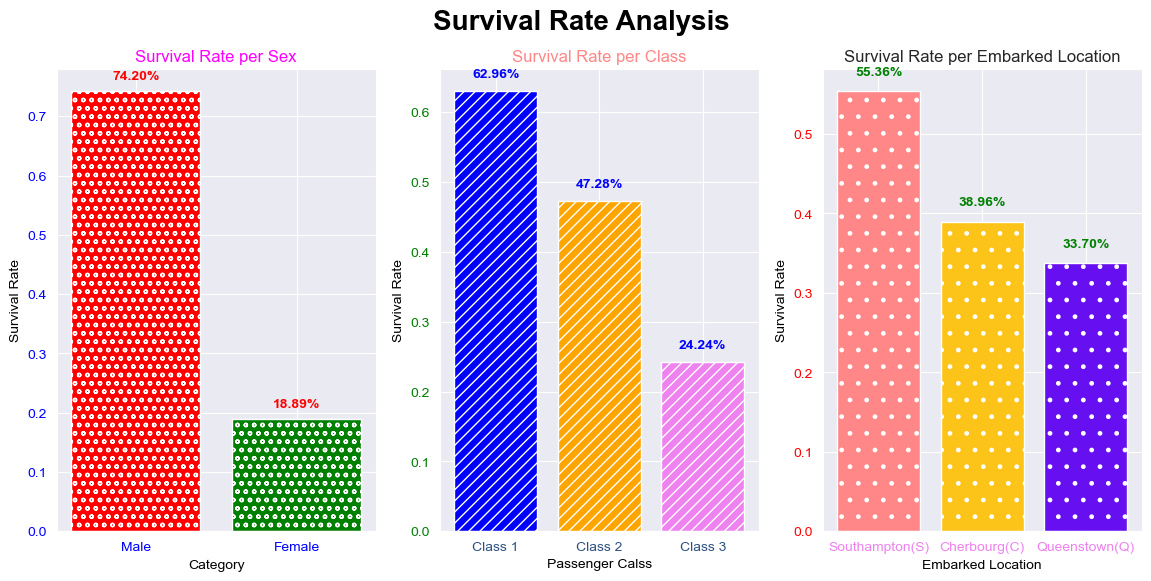

In [34]:
# survival rate 
fig,ax = plt.subplots(1,3,figsize = (14,6));
ax.flatten();

# 1. By sex
ax[0].bar(['Male','Female'],f['Survived'],hatch= 'oo',color = ['red','green']);
ax[0].set_xlabel('Category',c = 'black');
ax[0].set_ylabel('Survival Rate',c= 'black');
ax[0].set_title('Survival Rate per Sex',c = 'magenta');
for i,v in enumerate(f['Survived']):
    ax[0].text(i,v+0.02,f'{v:.2%}',fontweight = 'bold',ha = 'center',c = 'red');
ax[0].tick_params(axis = 'x',colors = 'b');
ax[0].tick_params(axis = 'y',colors = 'b');

# 2. By class
ax[1].bar(['Class 1','Class 2','Class 3'],c['Survived'],hatch = '///',color = ['blue','orange','violet']);
ax[1].set_xlabel('Passenger Calss',c = 'black');
ax[1].set_ylabel('Survival Rate',c = 'black');
ax[1].set_title('Survival Rate per Class',c = '#FF8787')
for k,y in enumerate(c['Survived']):
    ax[1].text(k,y+0.02,f'{y:.2%}',ha = 'center',fontweight = 'bold',color= 'blue');
ax[1].tick_params(axis = 'x',colors ='#2C5282') # (Dark Steel Blue)
ax[1].tick_params(axis = 'y',colors = 'green') # (Professional Azure Blue)
plt.suptitle('Survival Rate Analysis',fontweight = 'bold',color = 'black',fontsize = 20);

# 3. By Embarked
ax[2].bar(['Southampton(S)','Cherbourg(C)','Queenstown(Q)'],g['Survived'],hatch = '.',color = ['#FF8787','#FCC419','#6610F2'])
for d,w in enumerate(g['Survived']):
    ax[2].text(d,w+0.02,f'{w:.2%}',fontweight = 'bold',ha = 'center',color = 'green')
ax[2].set_xlabel('Embarked Location',c = 'black');
ax[2].set_ylabel('Survival Rate',c = 'black');
ax[2].set_title('Survival Rate per Embarked Location');
ax[2].tick_params(axis = 'y',colors = 'red')
ax[2].tick_params(axis = 'x',colors = 'violet')

In [35]:
d1 = df.groupby(['Pclass','Sex'])['Survived'].mean().unstack()
d1

Sex,female,male
Pclass,,
1,0.97,0.37
2,0.92,0.16
3,0.50,0.14


# *Survival Rate By Class and Sex*

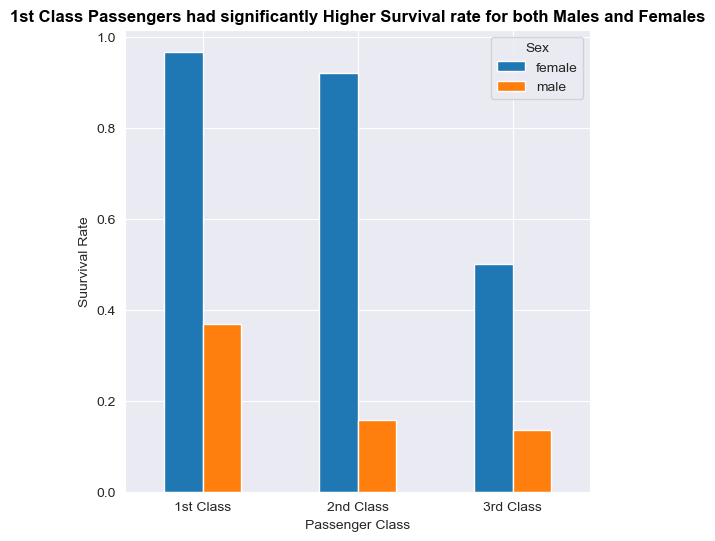

In [36]:
fig,ax = plt.subplots(figsize = (6,6));
d1.plot(kind = 'bar',ax = ax);
ax.set_xlabel('Passenger Class');
ax.set_ylabel('Suurvival Rate');
ax.set_title('1st Class Passengers had significantly Higher Survival rate for both Males and Females',c = 'black',fontweight = 'bold');
ax.set_xticklabels(['1st Class','2nd Class','3rd Class'],rotation = 0);


# *Analysing Age Distribution By Survival*

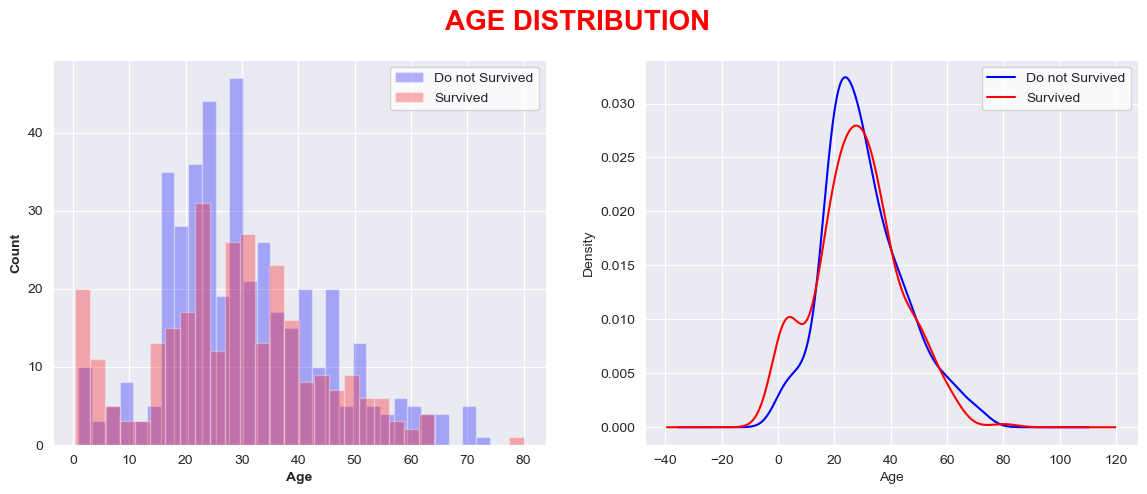

In [37]:
fig,ax = plt.subplots(1,2,figsize = (14,5));
ax.flatten()
sns.set_style('whitegrid')
# Histogram plot
ax[0].hist(df[df['Survived']==0]['Age'].dropna(),bins = 30,label = 'Do not Survived',color = 'blue',alpha = 0.3);
ax[0].hist(df[df['Survived']==1]['Age'].dropna(),bins = 30,label = 'Survived',color = 'red',alpha = 0.3);
ax[0].legend();
ax[0].set_xlabel('Age',fontweight = 'bold');
ax[0].set_ylabel('Count',fontweight = 'bold');
plt.suptitle('AGE DISTRIBUTION',fontweight = 'bold',fontsize = 20,color = 'red');

#KDE(Kernel Density Estimation) plot
df[df['Survived']==0]['Age'].plot.kde(ax=ax[1],color = 'blue',label = 'Do not Survived');
df[df['Survived']==1]['Age'].plot.kde(ax=ax[1],color = 'red',label = 'Survived');
ax[1].legend();
ax[1].set_xlabel('Age');

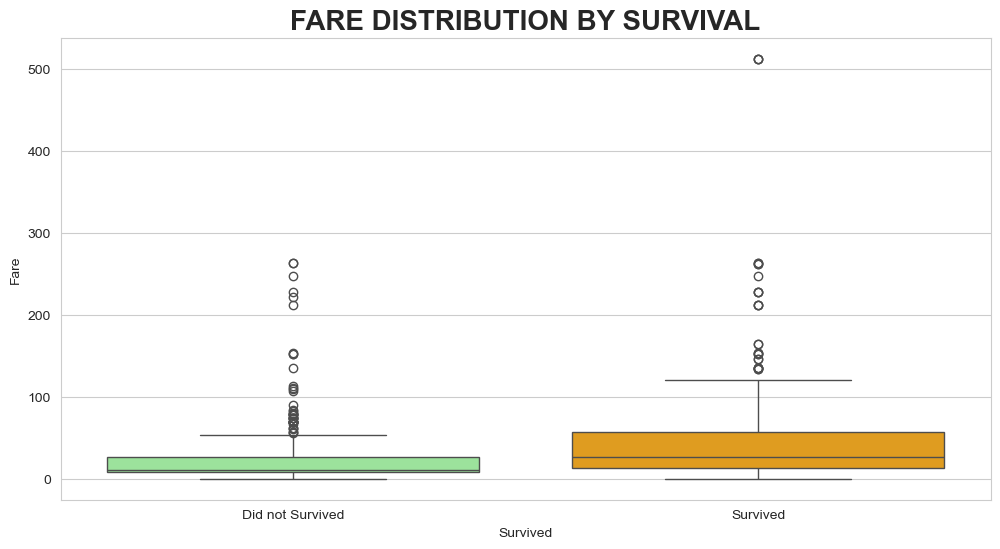

In [38]:
fig,ax = plt.subplots(figsize = (12,6));
sns.boxplot(x = 'Survived',y = 'Fare',data = df,palette = ['lightgreen','orange'],ax = ax);
ax.set_xticklabels(['Did not Survived','Survived']);
ax.set_title('FARE DISTRIBUTION BY SURVIVAL',fontweight = 'bold',fontsize = 20);

In [39]:
print(f'Average Fare - Survived : ${df[df['Survived']==1]['Fare'].mean():.2f}')
print(f'Average Fare - Do Not Survived : ${df[df['Survived']==0]['Fare'].mean():.2}')

Average Fare - Survived : $48.40
Average Fare - Do Not Survived : $2.2e+01


# *Observations*
* **Passengers who paid higher than average had more chance of survival**
* **This maps with the logic that higher class piad higher fares**

# *Family Trend*

In [40]:
df['Family_Size'] = df['Parch']+df['SibSp'] + 1 # count your ownself

In [41]:
family = df['Family_Size'].value_counts().reset_index()
family = family.set_index(family['Family_Size'])
family = family.drop(columns = {'Family_Size'})
family

,count
Family_Size,
1,537
2,161
3,102
4,29
6,22
5,15
7,12
11,7
8,6


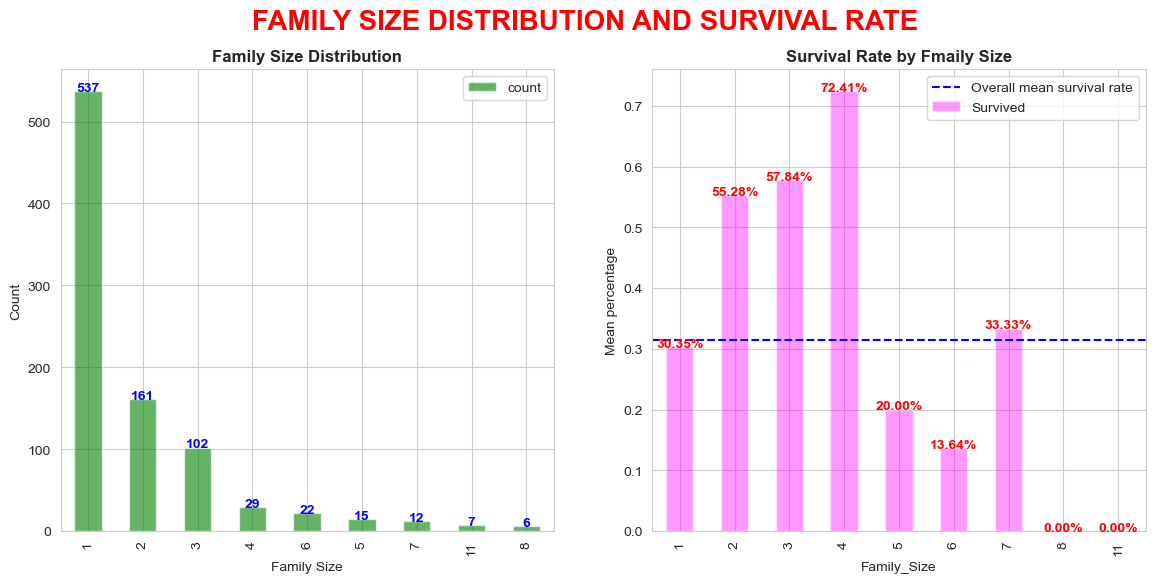

In [42]:
fig,ax = plt.subplots(1,2,figsize = (14,6))
texts = []
ax.flatten()
family.plot(kind = 'bar',color = 'green',ax = ax[0],alpha = 0.6);
ax[0].set_xlabel('Family Size');
ax[0].set_ylabel('Count');
ax[0].set_title('Family Size Distribution',fontweight = 'bold')
for i,v in enumerate(family['count']):
    t = ax[0].text(i,v,str(v),fontweight = 'bold',ha = 'center',color = 'blue');
    if i==9:
        t.remove();
ax[0].text(11,6,str(6),fontweight = 'bold',ha = 'center',color = 'blue');    

#Survival rate by family count
sns.set_style('whitegrid')
family_survive = df.groupby('Family_Size')['Survived'].mean().reset_index();
family_survive = family_survive.set_index(family_survive['Family_Size']);
family_survive = family_survive.drop(columns = {'Family_Size'});
family_survive.plot(kind = 'bar',alpha = 0.4,color  = 'magenta',ax = ax[1]);
for h,k in enumerate(family_survive['Survived']):
    ax[1].text(h,k,f'{k:.2%}',fontweight = 'bold',ha = 'center',color = 'red');
ax[1].set_ylabel('Mean percentage');
ax[1].set_title('Survival Rate by Fmaily Size',fontweight = 'bold');
plt.suptitle('FAMILY SIZE DISTRIBUTION AND SURVIVAL RATE',fontweight = 'bold',color  = 'red',fontsize = 20);
ax[1].axhline(family_survive['Survived'].mean(),linestyle = '--',color = 'blue',label = 'Overall mean survival rate');
ax[1].legend();

# *11. Correlation between the different numerical categories*

In [43]:
numeric = df[['Survived','Age','Family_Size','Sex','SibSp','Parch','Pclass','Fare']].copy()
numeric['Sex'] = df['Sex'].map({'male':0,'female':1}) # 0 means male 1 means female
corr = numeric.corr()
corr

,Survived,Age,Family_Size,Sex,SibSp,Parch,Pclass,Fare
Survived,1.00,-0.08,0.02,0.54,-0.04,0.08,-0.34,0.26
Age,-0.08,1.00,-0.30,-0.09,-0.31,-0.19,-0.37,0.10
Family_Size,0.02,-0.30,1.00,0.20,0.89,0.78,0.07,0.22
Sex,0.54,-0.09,0.20,1.00,0.11,0.25,-0.13,0.18
SibSp,-0.04,-0.31,0.89,0.11,1.00,0.41,0.08,0.16
Parch,0.08,-0.19,0.78,0.25,0.41,1.00,0.02,0.22
Pclass,-0.34,-0.37,0.07,-0.13,0.08,0.02,1.00,-0.55
Fare,0.26,0.10,0.22,0.18,0.16,0.22,-0.55,1.00


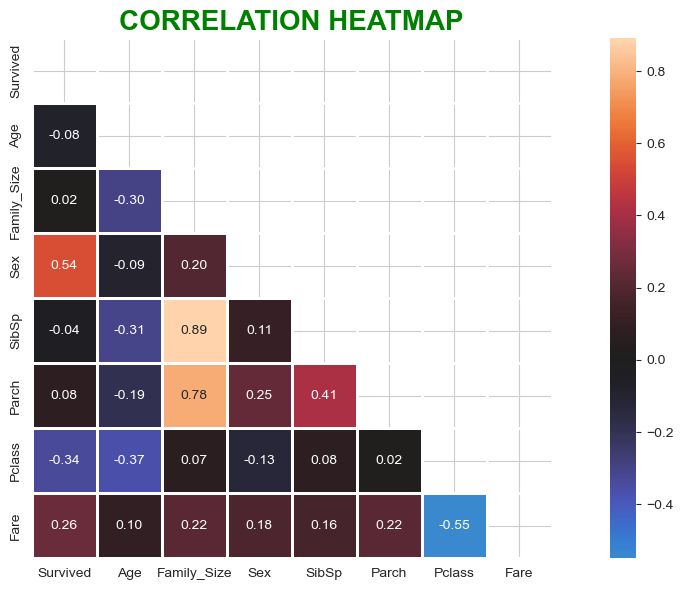

In [44]:
sns.set_style('whitegrid')
fig,axis = plt.subplots(figsize = (12,6))
mask = np.triu(np.ones_like(corr,dtype = bool))
sns.heatmap(corr,mask = mask,annot = True,center =0,fmt = ".2f",square = True,ax = axis,linewidths = 1);
axis.set_title('CORRELATION HEATMAP',fontweight = 'bold',color = 'green',fontsize = 20);
plt.tight_layout()

In [45]:
targeted_column = corr['Survived'].drop('Survived')
targeted_column = targeted_column.sort_values(ascending  = True)
targeted_column

Pclass        -0.34
Age           -0.08
SibSp         -0.04
Family_Size    0.02
Parch          0.08
Fare           0.26
Sex            0.54
Name: Survived, dtype: float64

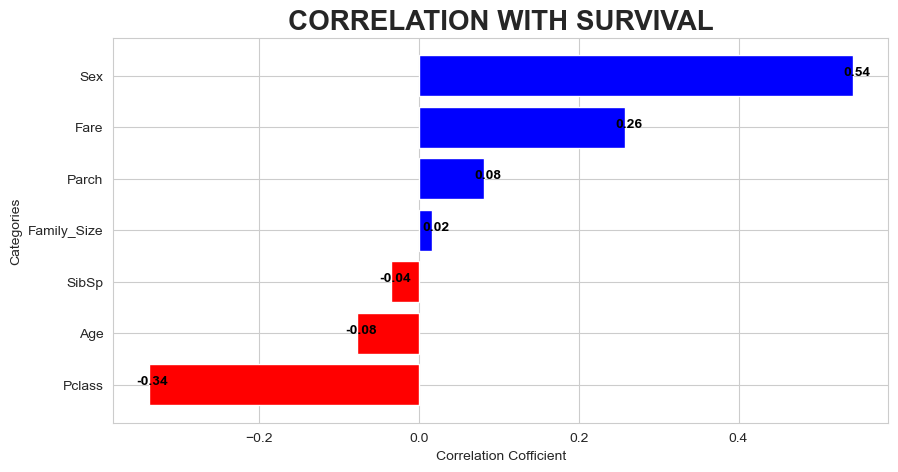

In [46]:
fig,ax = plt.subplots(figsize = (10,5));
colors = ['red' if i<0 else 'blue' for i in targeted_column.values ];
ax.barh(targeted_column.index,targeted_column.values,color = colors);
for j,v in enumerate(targeted_column.values):
    ax.text(v+0.005,j,str(f"{v:.2f}"),fontweight = 'bold',ha = 'center',color = 'black');
ax.set_xlabel('Correlation Cofficient');
ax.set_ylabel('Categories');
ax.set_title('CORRELATION WITH SURVIVAL',fontweight = 'bold',fontsize = 20);

## *Key Correlations with Survival Rate:*
|**CATEGORY**|**CORRELATION NATURE**|**OBSERVATION**|
|------------|----------------------|---------------|
|**Sex(Female)**|Strong Positive Correlation |: Being Female were the highest chance of Survival|
|**Fare**|Positive Correlation|: Higher class persons had higher chance of survival|
|**Pclass**|Negative Correlation|: 3rd class passengers had least chance of survival whereas 1st class passengers had higher chance of survival|
|**Age**|Slightly Negative Correlation|: Younger passengers had better survival chances|

# *12. Title Analysis and Visualization*

In [47]:
df.head(1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S,2


In [48]:
df['Title'] = df['Name'].apply(lambda x : x.split(',')[1].split('.')[0].strip())
df['Title']

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: object

In [49]:
title  = df['Title'].value_counts().reset_index()
title

,Title,count
0,Mr,517
1,Miss,182
2,Mrs,125
3,Master,40
4,Dr,7
5,Rev,6
6,Mlle,2
7,Major,2
8,Col,2
9,the Countess,1


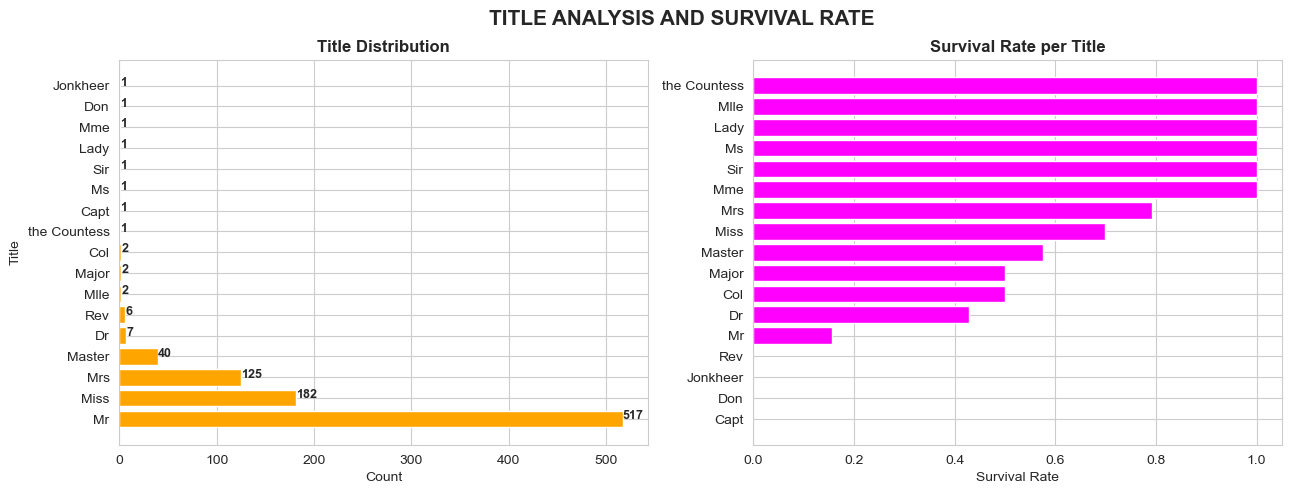

In [50]:
fig,ax = plt.subplots(1,2,figsize = (15,5));
ax.flatten();
# Title distribution
ax[0].barh(title['Title'],title['count'],color = 'orange');
for x,v in enumerate(title['count']):
    ax[0].text(v,x,str(v),fontweight = 'bold',fontsize = 9);
ax[0].set_xlabel('Count');
ax[0].set_ylabel('Title');
ax[0].set_title('Title Distribution',fontweight = 'bold');

survive = df.groupby('Title')['Survived'].mean().sort_values(ascending = True).reset_index();
ax[1].barh(survive['Title'],survive['Survived'],color = 'magenta');
ax[1].set_xlabel('Survival Rate');
ax[1].set_title('Survival Rate per Title',fontweight = 'bold');
plt.suptitle('TITLE ANALYSIS AND SURVIVAL RATE',fontweight = 'bold',fontsize = 15);

# 13. *SUMMARY*

|**CONCLUSION**|**DETAIL**|
|--------------|----------|
|**Imbalance :**| ~ 38% Survived,~62% did not|
|**Sex is the strongest Predictor**| Females survival rate was ~74% and males was ~19.9%|
|**Class has importance**|1st Class : ~63% Survived 3rd Class: 24% Survived|
|**Age**|Children had higher survival rate with rate going down as age increases to elder age group|
|**Fare**|Survivors Paid Significantly Higher Fares|
|**Family Size**|Small family Size (2-4) had highest survival rate|
|**Title**|Mlle,Lady,Ms,Sir,Mme,Mrs,Miss had higher survival , Mr has least|
|**Embarkation**|Southampton had highest survival ~55%|